In [2]:
# Setup
# Cell 1: Setup
import data_loader
import importlib
importlib.reload(data_loader)


# print(f"Box size1: {BOX_SIZE}")

# Setup
from data_loader import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

print("BOX_SIZE2:", BOX_SIZE)


plt.rcParams.update({'font.size': 14})


def autocorr(x, max_lag):
    """
    Normalized autocorrelation function C(tau)
    """
    x = np.asarray(x)
    x = x - x.mean()
    var = np.mean(x**2)

    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        acf[tau] = np.mean(x[:-tau or None] * x[tau:]) / var

    return acf

Loading bubble data...
✓ Loaded 139446 observations
Empty DataFrame
Columns: [id, x, y, area, pressure, Z]
Index: []
✓ Timesteps added: 0 to 725
✓ Identified 300 disappearing bubbles
Applying periodic boundary corrections...
✓ Periodic boundary correction applied
✓ Derived quantities computed

DATA LOADING COMPLETE
Total observations:       139,446
Unique bubbles:           400
Timesteps:                0 to 725
Disappearing bubbles:     300
Box size:                 20.203051
Initial avg area (A_0):   1.000000

Available variables:
  - df: Original dataframe
  - df_corrected: Corrected dataframe with actual_area column
  - disappearing_ids: Set of disappearing bubble IDs
  - bubbles_per_timestep: Number of bubbles at each timestep
  - avg_area_per_timestep: Average bubble area at each timestep
  - approx_avg_area: Approximate area from liquid fraction
  - A_0: Initial average bubble area
  - max_timestep: Maximum timestep
  - final_step: Final timestep
  - box_area: Total box area
  -

In [3]:
# Make globally positive coordinates for x and y
min_x = df_corrected["x"].min()
min_y = df_corrected["y"].min()


offset_x = 1.0 - min_x   # ensures min Sx ≈ 1
offset_y = 1.0 - min_y


df_corrected["Sx"] = df_corrected["x"] + offset_x
df_corrected["Sy"] = df_corrected["y"] + offset_y



# Function to get signed log-returns
def get_signed_logreturns_bubbles(dt):
    """Return pooled signed log-returns r_x, r_y for all bubbles at lag dt."""
    log_ret_x, log_ret_y = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        Sx = g["Sx"].to_numpy()
        Sy = g["Sy"].to_numpy()

        if len(Sx) <= dt:
            continue

        r_x = np.log(Sx[dt:] / Sx[:-dt])
        r_y = np.log(Sy[dt:] / Sy[:-dt])

        log_ret_x.extend(r_x)
        log_ret_y.extend(r_y)

    
    # Plot x and y log-returns separately 
    plt.figure(figsize=(10,4))
    plt.plot(np.arange(len(log_ret_x)), log_ret_x, alpha=0.8, label='Log-Return X')
    plt.plot(np.arange(len(log_ret_y)), np.array(log_ret_y) - 0.3, alpha=0.8, label='Log-Return Y')
    plt.xlabel("Time")
    plt.ylabel("Log-Return")
    plt.title(f"Log-Returns")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    #plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/10_Figures/log_returns_xy_seperate_2.png", dpi=300, bbox_inches='tight')
    plt.show()

    log_ret = np.sqrt(np.array(log_ret_x)**2 + np.array(log_ret_y)**2)
    log_ret = log_ret - log_ret.mean()     # recentre (should be ~0 anyway)
    return log_ret 



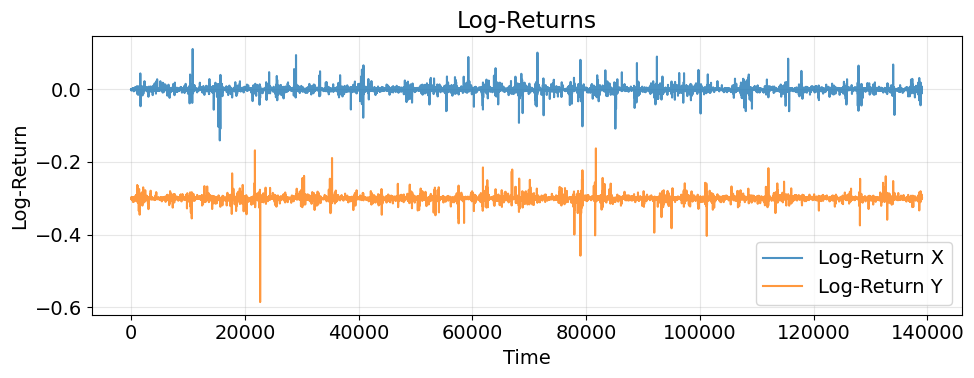

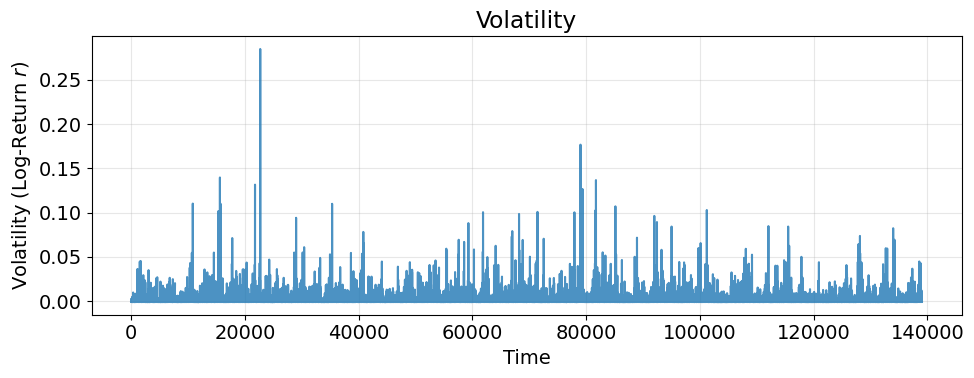

In [4]:
# Get log-returns for dt=1    
log_ret = get_signed_logreturns_bubbles(dt=1)
time = np.arange(len(log_ret))

# Plot Log-Returns over Time
plt.figure(figsize=(10,4))
plt.plot(time, log_ret, alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Volatility (Log-Return $r$)")
plt.title("Volatility")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/10_Figures/volatility_2.png", dpi=300, bbox_inches='tight')






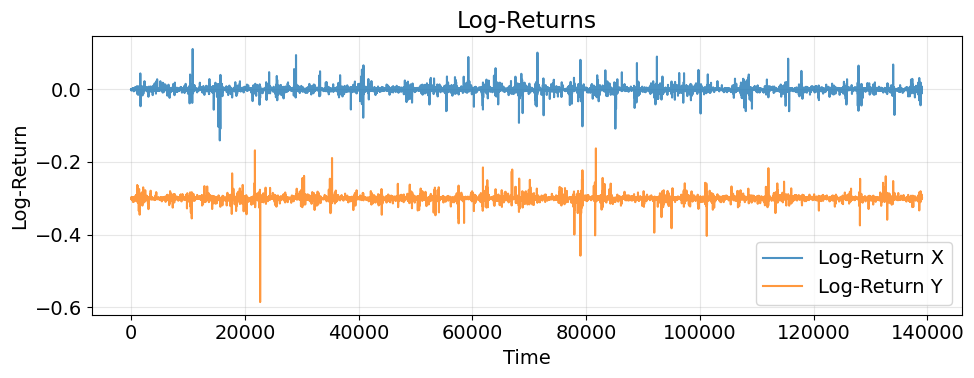

log-return correlation time τ_c ≈ 6.73 frames


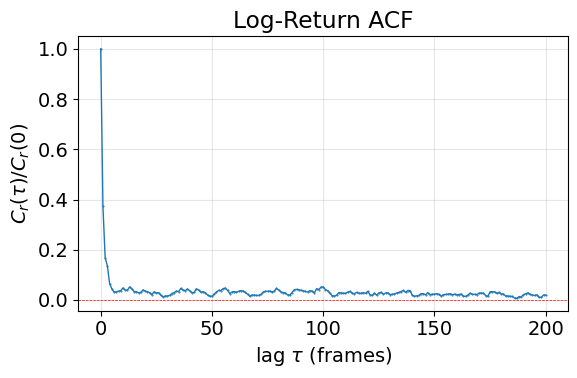

log-return correlation time τ_c ≈ 6.73 frames


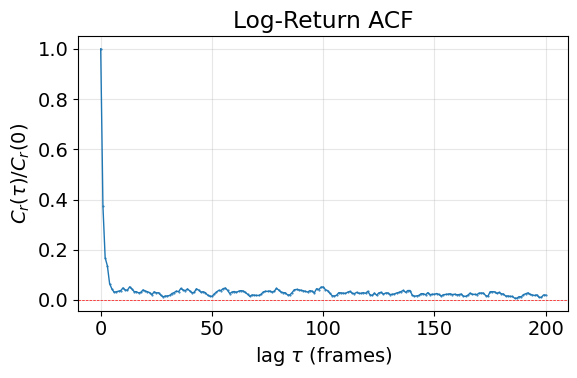

In [5]:
# --- helpers copied from 09 ---
def scalar_acf_fft(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None or max_lag > n - 1:
        max_lag = n - 1
    x = x - np.mean(x)
    nfft = 1 << (2 * n - 1).bit_length()
    f = np.fft.rfft(x, n=nfft)
    p = f * np.conjugate(f)
    acf = np.fft.irfft(p, n=nfft)[:n]
    norm = np.arange(n, 0, -1, dtype=float)
    acf = acf / norm
    return acf[:max_lag + 1]


def scalar_acf_direct_normed(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None or max_lag > n - 1:
        max_lag = n - 1

    x = x - x.mean()
    var = np.mean(x * x)
    if var == 0:
        return np.zeros(max_lag + 1)

    acf = np.empty(max_lag + 1, dtype=float)
    for tau in range(max_lag + 1):
        acf[tau] = np.mean(x[:n - tau] * x[tau:]) / var
    return acf

def scalar_acf_direct_nonstationary(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None or max_lag > n - 1:
        max_lag = n - 1

    x = x - x.mean()

    acf = np.empty(max_lag + 1, dtype=float)
    for tau in range(max_lag + 1):
        x_t   = x[:n - tau]
        x_t_tau = x[tau:]

        sigma_t     = np.std(x_t)
        sigma_t_tau = np.std(x_t_tau)

        denom = sigma_t * sigma_t_tau
        if denom == 0:
            acf[tau] = 0.0
        else:
            acf[tau] = np.mean(x_t * x_t_tau) / denom

    return acf


def correlation_time(lags, C_norm, stop_at_zero_cross=True):
    lags = np.asarray(lags)
    C_norm = np.asarray(C_norm)
    if stop_at_zero_cross:
        mask = np.where(C_norm[1:] <= 0)[0]
        if len(mask) > 0:
            cut = mask[0] + 1
            lags = lags[:cut]
            C_norm = C_norm[:cut]
    return np.trapezoid(C_norm, lags)

# --- choose the log-return series to analyse ---
dt_for_acf = 1                # set the Δt you want
all_r = get_signed_logreturns_bubbles(dt_for_acf)   # or reuse existing all_r

# --- compute ACF on log returns ---
max_lag = min(200, len(all_r) - 1)
C = scalar_acf_direct_nonstationary(all_r, max_lag=max_lag)
C_norm = C / C[0]
lags = np.arange(max_lag + 1)
tau_c_r = correlation_time(lags, C_norm)

print(f"log-return correlation time τ_c ≈ {tau_c_r:.2f} frames")

plt.figure(figsize=(6,4))
plt.plot(lags, C_norm, marker='o', ms=0.5, lw=1)
plt.axhline(0, color='red', lw=0.5, ls='--')
plt.xlabel(r"lag $\tau$ (frames)")
plt.ylabel(r"$C_r(\tau)/C_r(0)$")
plt.title(f"Log-Return ACF")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/09.5_Figures/logreturn_acf_dt1.png", dpi=300, bbox_inches='tight')
plt.show()

max_lag = min(200, len(all_r) - 1)
C = scalar_acf_direct_normed(all_r, max_lag=max_lag)
C_norm = C / C[0]
lags = np.arange(max_lag + 1)
tau_c_r = correlation_time(lags, C_norm)

print(f"log-return correlation time τ_c ≈ {tau_c_r:.2f} frames")

plt.figure(figsize=(6,4))
plt.plot(lags, C_norm, marker='o', ms=0.5, lw=1)
plt.axhline(0, color='red', lw=0.5, ls='--')
plt.xlabel(r"lag $\tau$ (frames)")
plt.ylabel(r"$C_r(\tau)/C_r(0)$")
plt.title(f"Log-Return ACF")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/09.5_Figures/logreturn_acf_dt1.png", dpi=300, bbox_inches='tight')
plt.show()


In [6]:
def autocorr(x, max_lag):
    x = np.asarray(x)
    N = len(x)

    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        acf[tau] = np.sum(x[:N-tau] * x[tau:]) / N

    return acf

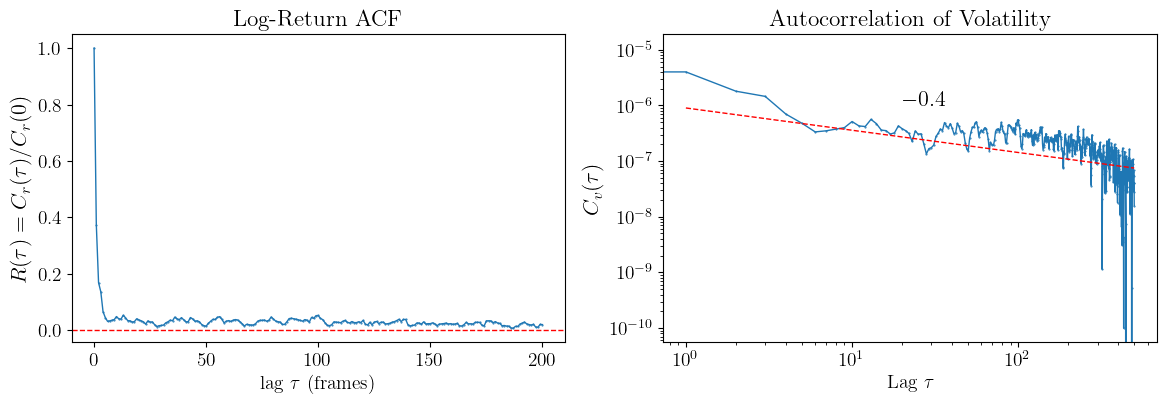

In [7]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})

fig, axs = plt.subplots(1, 2, figsize=(14,4))
axs = axs.ravel()



axs[0].plot(lags, C_norm, marker='o', ms=0.5, lw=1)
axs[0].axhline(0, color='red', lw=1, ls='--')
axs[0].set_xlabel(r"lag $\tau$ (frames)", fontsize=14)
axs[0].set_ylabel(r"$R(\tau) = C_r(\tau)/C_r(0)$", fontsize=16)
axs[0].set_title(f"Log-Return ACF")

max_lag = 500  # choose based on dataset size
acf_vol = autocorr(log_ret, max_lag)



axs[1].loglog(acf_vol, lw=1, marker='o', ms=0.5)
#plt.axhline(0, color='red', lw=0.5, ls='--')
#plt.xlim(0, 50)
#fit a linear line
tau = np.arange(1, len(acf_vol), dtype=float)
f_ref = 0.0000009 * tau**(-0.4)
axs[1].loglog(tau, f_ref, color = "red", lw=1, ls='--')
axs[1].text(20, 1e-6, r"$-0.4$", fontsize=16)
axs[1].set_xlabel(r"Lag $\tau$")
axs[1].set_ylabel(r"$C_v(\tau)$", fontsize=16)
axs[1].set_title("Autocorrelation of Volatility")
plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/00_Thesis_Figures/lr_volatility_acf_1x2.png", dpi=300, bbox_inches='tight')
plt.show()